In [1]:
# Kaggle already has all these — this just confirms versions
import sys
print("Python:", sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error

import joblib
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("\nLibrary versions:")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
import sklearn; print(f"  sklearn    {sklearn.__version__}")
print("\n✅  All imports successful")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Library versions:
  numpy      2.4.6
  pandas     2.3.3
  sklearn    1.6.1

✅  All imports successful


In [2]:
rng = np.random.default_rng(42)
n   = 1500

# Categorical pools
neighborhoods = ['NridgHt','CollgCr','OldTown','Edwards','Somerst',
                 'Gilbert','NWAmes','Sawyer','Mitchel','BrkSide']
house_styles  = ['1Story','2Story','1.5Fin','SFoyer','SLvl']
sale_conds    = ['Normal','Abnorml','Partial','AdjLand','Alloca','Family']
garage_types  = ['Attchd','Detchd','BuiltIn','CarPort','Basment']
bsmt_quals    = ['Ex','Gd','TA','Fa','Po']

# Numeric features with realistic distributions
overall_qual  = rng.integers(1, 11, n)
year_built    = rng.integers(1900, 2011, n)
gr_liv_area   = (overall_qual * 150 + rng.normal(800, 200, n)).clip(400, 4000).astype(int)
total_bsmt    = (gr_liv_area * rng.uniform(0.4, 0.9, n)).astype(int)
garage_cars   = rng.integers(0, 4, n)
garage_area   = (garage_cars * 220 + rng.normal(0, 50, n)).clip(0, 1500).astype(int)
bedrooms      = rng.integers(1, 7, n)
full_bath     = rng.integers(1, 4, n)
fireplaces    = rng.integers(0, 4, n)
yr_sold       = rng.integers(2006, 2011, n)
yr_remod      = np.minimum(year_built + rng.integers(0, 40, n), 2010)

# Price formula — realistic relationships
sale_price = (
    overall_qual * 18000
    + gr_liv_area  * 55
    + total_bsmt   * 20
    + garage_area  * 30
    + (2010 - year_built) * -200
    + bedrooms     * 3000
    + full_bath    * 8000
    + fireplaces   * 5000
    + rng.normal(0, 15000, n)
).clip(50000, 800000).astype(int)

df = pd.DataFrame({
    'Neighborhood' : rng.choice(neighborhoods, n),
    'HouseStyle'   : rng.choice(house_styles, n),
    'OverallQual'  : overall_qual,
    'OverallCond'  : rng.integers(1, 10, n),
    'YearBuilt'    : year_built,
    'YearRemodAdd' : yr_remod,
    'GrLivArea'    : gr_liv_area,
    'TotalBsmtSF'  : total_bsmt.astype(float),
    'BsmtQual'     : rng.choice(bsmt_quals, n),
    'GarageType'   : rng.choice(garage_types, n),
    'GarageCars'   : garage_cars,
    'GarageArea'   : garage_area.astype(float),
    'BedroomAbvGr' : bedrooms,
    'FullBath'     : full_bath,
    'HalfBath'     : rng.integers(0, 2, n),
    'TotRmsAbvGrd' : bedrooms + full_bath + rng.integers(1, 4, n),
    'Fireplaces'   : fireplaces,
    'LotArea'      : rng.integers(3000, 25000, n),
    'CentralAir'   : rng.choice(['Y','N'], n, p=[0.85, 0.15]),
    'MoSold'       : rng.integers(1, 13, n),
    'YrSold'       : yr_sold,
    'SaleCondition': rng.choice(sale_conds, n),
    'SalePrice'    : sale_price,
})

# Inject ~5% missing values in realistic columns
for col, rate in [('GarageType',0.06),('BsmtQual',0.05),
                  ('TotalBsmtSF',0.03),('GarageArea',0.04)]:
    mask = rng.random(n) < rate
    df.loc[mask, col] = np.nan

# Inject 12 duplicate rows
df = pd.concat([df, df.sample(12, random_state=42)], ignore_index=True)

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"SalePrice range: ${df['SalePrice'].min():,} – ${df['SalePrice'].max():,}")
print(f"Missing values : {df.isnull().sum().sum()} total cells")
print(f"Duplicate rows : {df.duplicated().sum()}")
df.head(3)


Dataset shape  : 1,512 rows × 23 columns
SalePrice range: $50,000 – $441,427
Missing values : 287 total cells
Duplicate rows : 12


,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,GrLivArea,TotalBsmtSF,BsmtQual,GarageType,...,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,LotArea,CentralAir,MoSold,YrSold,SaleCondition,SalePrice
0,CollgCr,SLvl,1,3,1958,1965,1142,NaN,Po,CarPort,...,1,0,7,1,7346,N,6,2006,Alloca,145356
1,Somerst,SLvl,8,5,1928,1943,1855,1092.0,Ex,Detchd,...,1,1,7,3,3902,Y,10,2009,Abnorml,294571
2,NWAmes,SLvl,7,3,1925,1943,1679,1334.0,Gd,Basment,...,3,0,8,3,11871,Y,1,2008,AdjLand,292714


In [3]:
print("=" * 55)
print("SHAPE")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

print("\n" + "=" * 55)
print("DATA TYPES")
print("=" * 55)
numeric_cols    = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"  Numeric ({len(numeric_cols)})    : {numeric_cols}")
print(f"  Categorical ({len(categorical_cols)}) : {categorical_cols}")

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col, cnt in missing.items():
    pct = cnt / len(df) * 100
    print(f"  {col:<20} {cnt:>5,}  ({pct:.1f}%)")

print("\n" + "=" * 55)
print("DUPLICATE ROWS")
print("=" * 55)
dupes = df.duplicated().sum()
print(f"  {dupes} duplicate rows ({dupes/len(df)*100:.1f}%)")

print("\n" + "=" * 55)
print("STATISTICAL SUMMARY (numeric)")
print("=" * 55)
df[['OverallQual','GrLivArea','TotalBsmtSF','GarageArea','LotArea','SalePrice']].describe().round(1)


SHAPE
  Rows    : 1,512
  Columns : 23

DATA TYPES
  Numeric (17)    : ['OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea', 'MoSold', 'YrSold', 'SalePrice']
  Categorical (6) : ['Neighborhood', 'HouseStyle', 'BsmtQual', 'GarageType', 'CentralAir', 'SaleCondition']

MISSING VALUES
  GarageType              87  (5.8%)
  BsmtQual                86  (5.7%)
  GarageArea              65  (4.3%)
  TotalBsmtSF             49  (3.2%)

DUPLICATE ROWS
  12 duplicate rows (0.8%)

STATISTICAL SUMMARY (numeric)


,OverallQual,GrLivArea,TotalBsmtSF,GarageArea,LotArea,SalePrice
count,1512.0,1512.0,1463.0,1447.0,1512.0,1512.0
mean,5.6,1625.5,1052.3,331.5,14037.3,243618.3
std,2.9,475.3,399.1,240.8,6330.4,84334.2
min,1.0,400.0,231.0,0.0,3012.0,50000.0
25%,3.0,1252.8,752.0,120.5,8387.2,173824.2
50%,6.0,1636.0,1007.0,304.0,14073.5,245560.5
75%,8.0,1995.2,1326.0,520.0,19438.2,312019.8
max,10.0,2871.0,2367.0,818.0,24998.0,441427.0


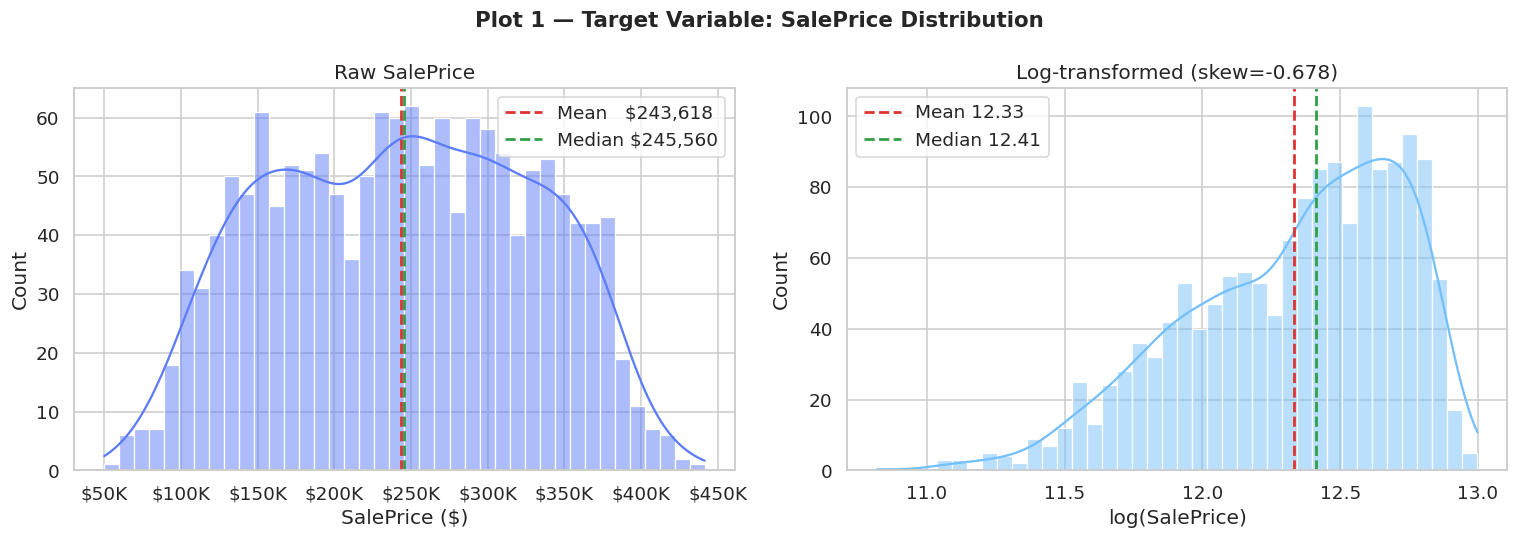

Raw skew: -0.021  |  Log skew: -0.678


In [4]:
# ── Plot 1: SalePrice distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 1 — Target Variable: SalePrice Distribution",
             fontsize=14, fontweight="bold")

sns.histplot(df['SalePrice'], kde=True, bins=40, color="#5C7CFA", ax=axes[0])
axes[0].axvline(df['SalePrice'].mean(),   color="#E03131", lw=1.8, linestyle="--",
                label=f"Mean   ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color="#2F9E44", lw=1.8, linestyle="--",
                label=f"Median ${df['SalePrice'].median():,.0f}")
axes[0].set_title("Raw SalePrice")
axes[0].set_xlabel("SalePrice ($)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

log_price = np.log1p(df['SalePrice'])
sns.histplot(log_price, kde=True, bins=40, color="#74C0FC", ax=axes[1])
axes[1].axvline(log_price.mean(),   color="#E03131", lw=1.8, linestyle="--",
                label=f"Mean {log_price.mean():.2f}")
axes[1].axvline(log_price.median(), color="#2F9E44", lw=1.8, linestyle="--",
                label=f"Median {log_price.median():.2f}")
axes[1].set_title(f"Log-transformed (skew={log_price.skew():.3f})")
axes[1].set_xlabel("log(SalePrice)")
axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Raw skew: {df['SalePrice'].skew():.3f}  |  Log skew: {log_price.skew():.3f}")


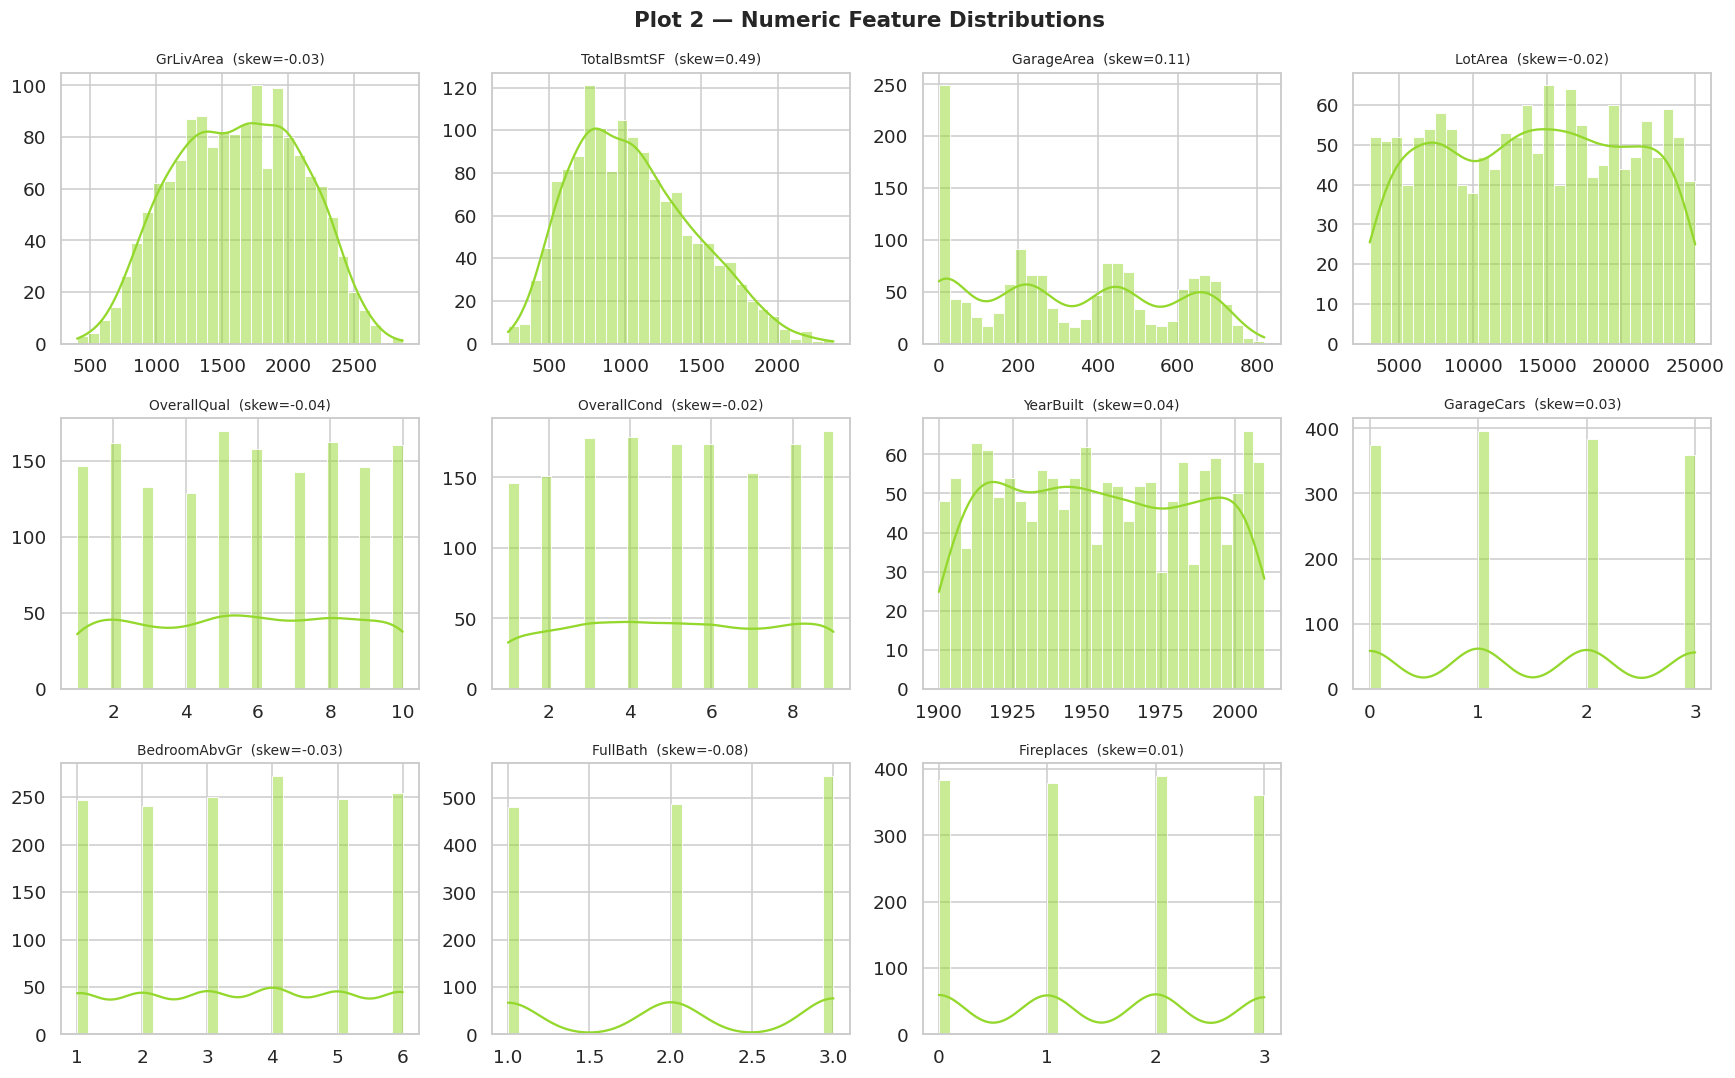

Features with |skew| > 1: []


In [5]:
# ── Plot 2: Numeric feature distributions ─────────────────────────────
num_feats = ['GrLivArea','TotalBsmtSF','GarageArea','LotArea',
             'OverallQual','OverallCond','YearBuilt','GarageCars',
             'BedroomAbvGr','FullBath','Fireplaces']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Plot 2 — Numeric Feature Distributions", fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

for i, col in enumerate(num_feats):
    clean = df[col].dropna()
    sns.histplot(clean, kde=True, bins=30, color="#94D82D", ax=axes_flat[i])
    axes_flat[i].set_title(f"{col}  (skew={clean.skew():.2f})", fontsize=9)
    axes_flat[i].set_xlabel(""); axes_flat[i].set_ylabel("")

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout(); plt.show()
skewed = [c for c in num_feats if abs(df[c].dropna().skew()) > 1]
print(f"Features with |skew| > 1: {skewed}")


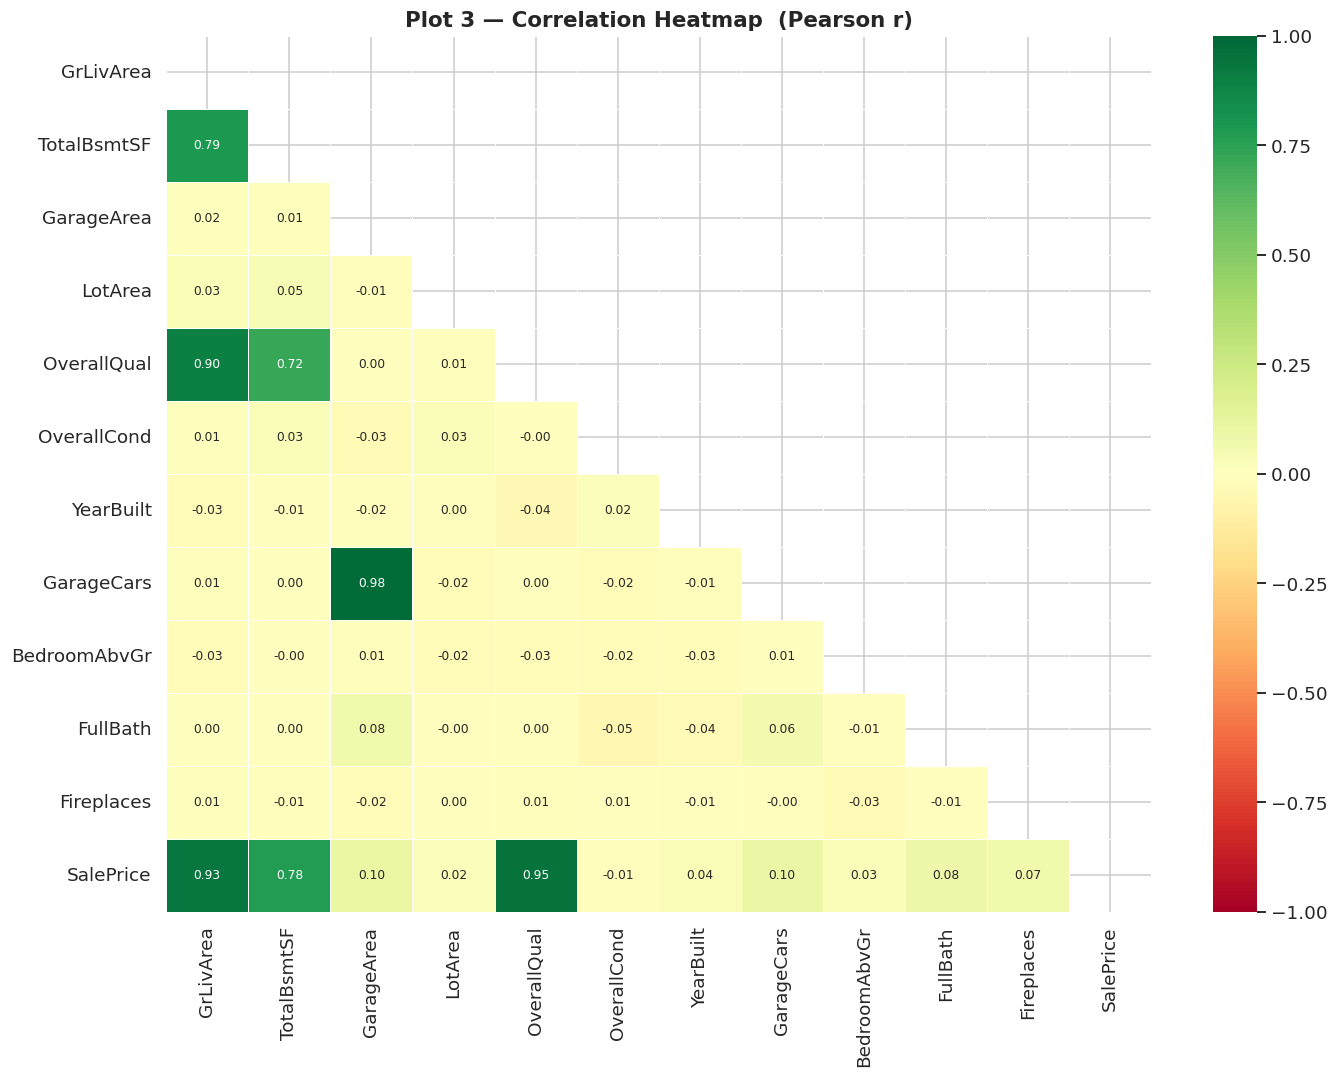


Top correlations with SalePrice:
  OverallQual          +0.953  ███████████████████
  GrLivArea            +0.934  ██████████████████
  TotalBsmtSF          +0.775  ███████████████
  GarageArea           +0.103  ██
  GarageCars           +0.098  █
  FullBath             +0.082  █
  Fireplaces           +0.073  █
  YearBuilt            +0.037  
  BedroomAbvGr         +0.031  
  LotArea              +0.017  
  OverallCond          -0.013  


In [6]:
# ── Plot 3: Correlation heatmap ────────────────────────────────────────
num_df = df[num_feats + ['SalePrice']].copy()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size":8}, ax=ax)
ax.set_title("Plot 3 — Correlation Heatmap  (Pearson r)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nTop correlations with SalePrice:")
top = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)
for feat, val in top.items():
    bar = "█" * int(abs(val)*20)
    print(f"  {feat:<20} {val:+.3f}  {bar}")


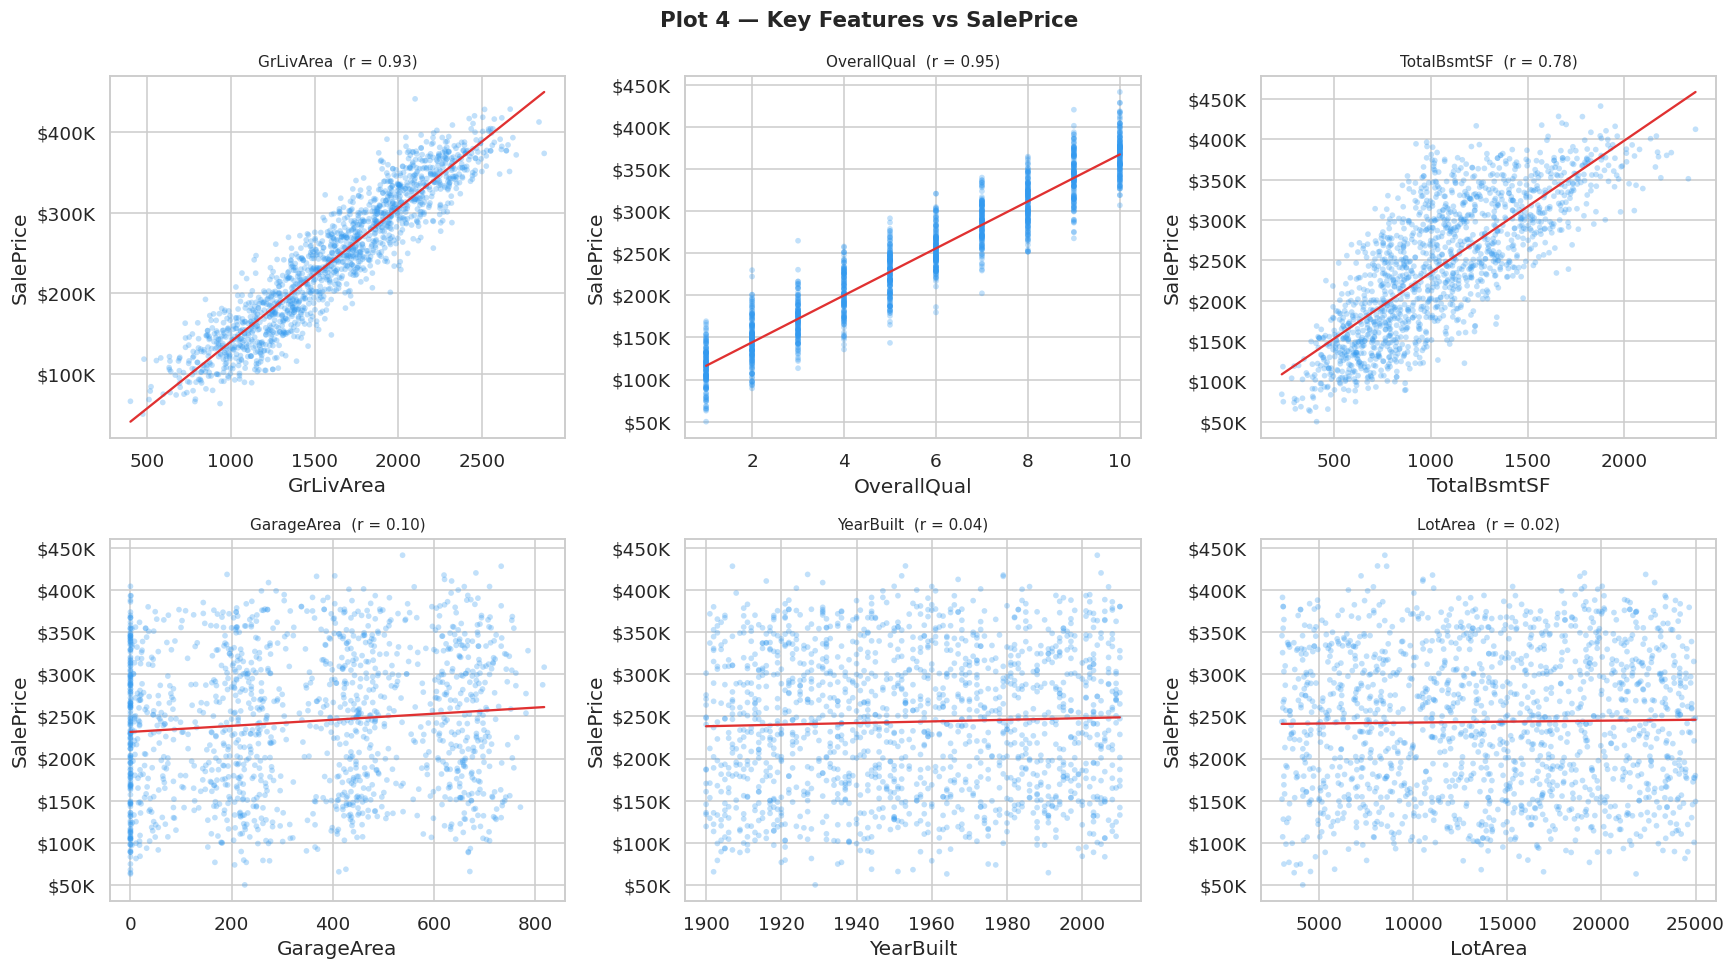

In [7]:
# ── Plot 4: Scatter plots ─────────────────────────────────────────────
top_scatter = ['GrLivArea','OverallQual','TotalBsmtSF',
               'GarageArea','YearBuilt','LotArea']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Plot 4 — Key Features vs SalePrice", fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, top_scatter):
    clean = df[[col,'SalePrice']].dropna()
    ax.scatter(clean[col], clean['SalePrice'], alpha=0.3, s=14,
               color="#339AF0", edgecolors="none")
    m, b   = np.polyfit(clean[col], clean['SalePrice'], 1)
    x_line = np.linspace(clean[col].min(), clean[col].max(), 200)
    ax.plot(x_line, m*x_line+b, color="#E03131", lw=1.5)
    r = clean[[col,'SalePrice']].corr().iloc[0,1]
    ax.set_title(f"{col}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel(col); ax.set_ylabel("SalePrice")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

plt.tight_layout(); plt.show()


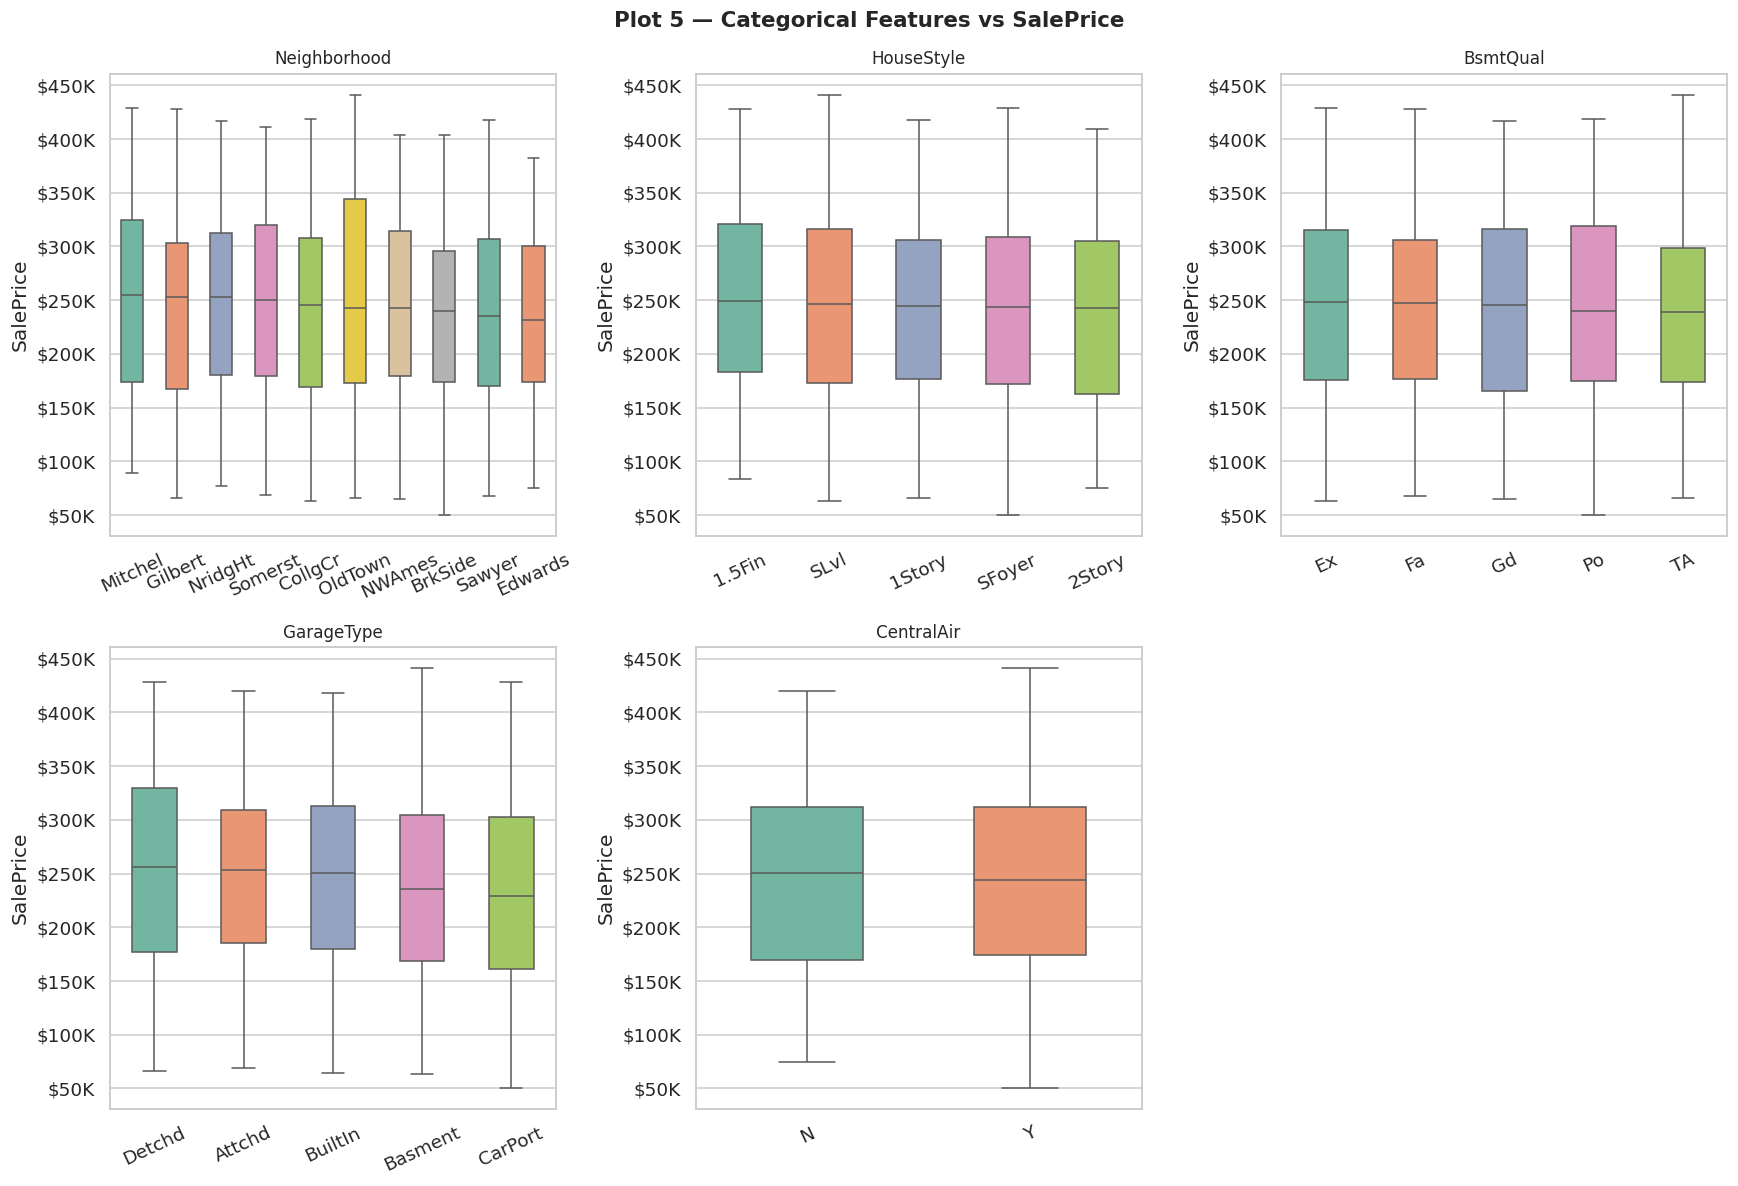

In [8]:
# ── Plot 5: Box plots — categoricals vs SalePrice ─────────────────────
cat_feats = ['Neighborhood','HouseStyle','BsmtQual','GarageType','CentralAir']

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle("Plot 5 — Categorical Features vs SalePrice", fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cat_feats):
    clean = df[[col,'SalePrice']].dropna()
    order = clean.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=clean, x=col, y='SalePrice', order=order,
                palette="Set2", width=0.5, fliersize=3, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.tick_params(axis='x', rotation=25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

axes_flat[-1].set_visible(False)
plt.tight_layout(); plt.show()


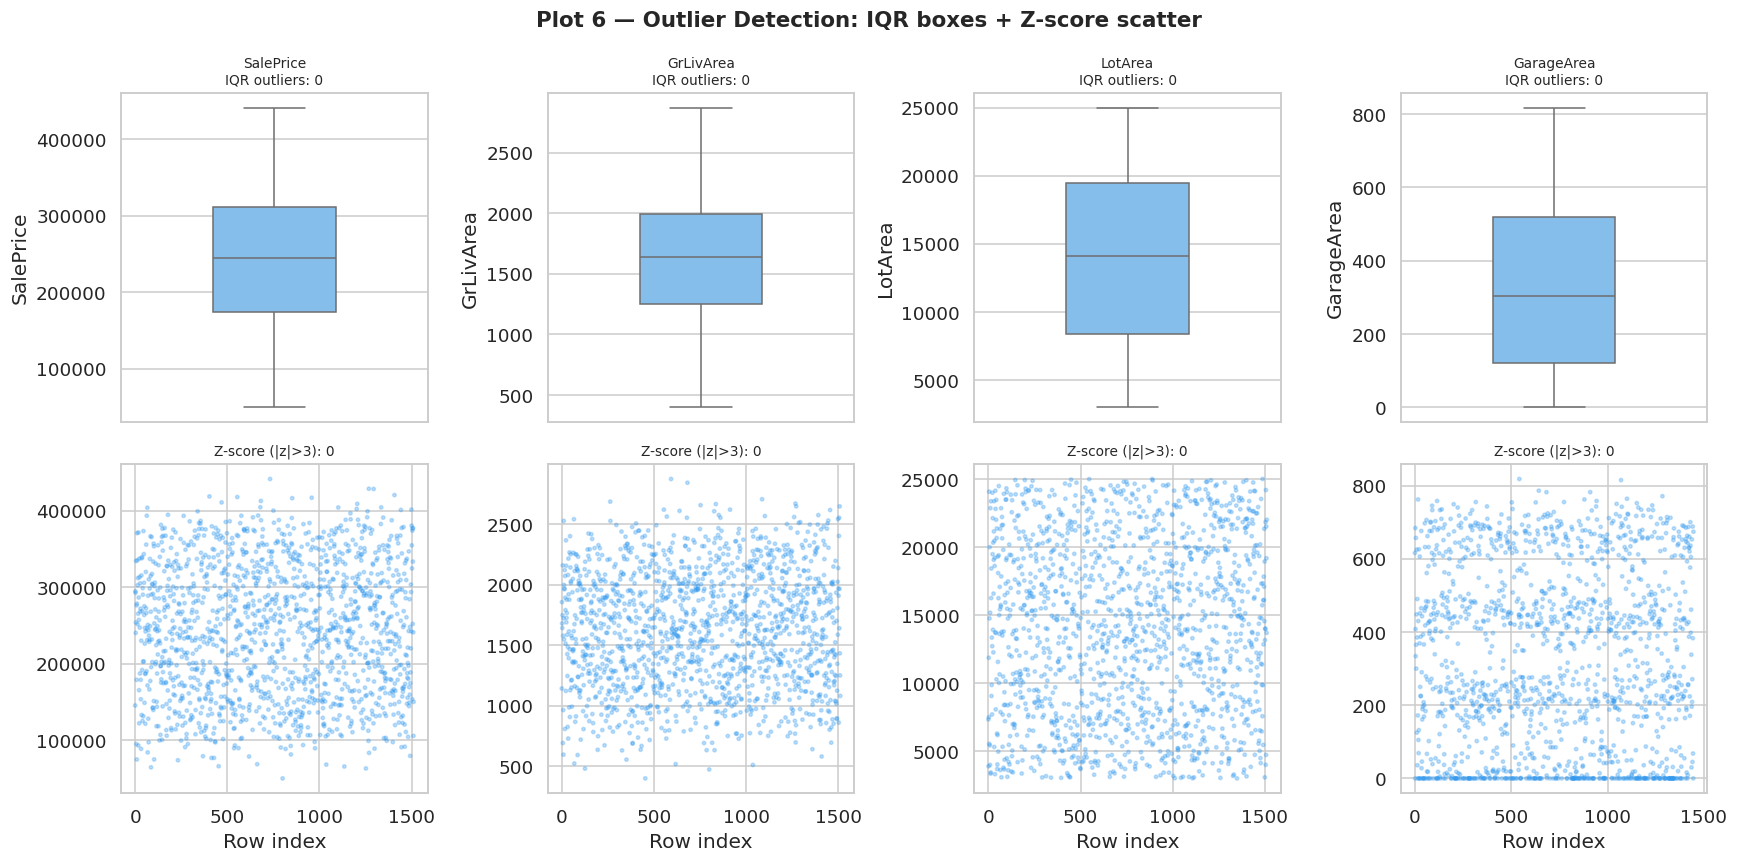

In [9]:
# ── Plot 6: Outlier detection (IQR + Z-score) ─────────────────────────
outlier_cols = ['SalePrice','GrLivArea','LotArea','GarageArea']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Plot 6 — Outlier Detection: IQR boxes + Z-score scatter",
             fontsize=14, fontweight="bold")

for i, col in enumerate(outlier_cols):
    clean = df[col].dropna()

    # IQR box plot
    Q1, Q3 = clean.quantile(0.25), clean.quantile(0.75)
    lo, hi  = Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)
    n_iqr   = ((clean < lo) | (clean > hi)).sum()
    ax_box  = axes[0][i]
    sns.boxplot(y=clean, color="#74C0FC", width=0.4,
                flierprops={"markerfacecolor":"#E03131","marker":"o","markersize":4}, ax=ax_box)
    ax_box.set_title(f"{col}\nIQR outliers: {n_iqr}", fontsize=9)

    # Z-score scatter
    z = np.abs(stats.zscore(clean))
    n_z   = (z > 3).sum()
    ax_z  = axes[1][i]
    colors = ["#E03131" if zi > 3 else "#339AF0" for zi in z]
    ax_z.scatter(range(len(clean)), clean, s=5, alpha=0.3, c=colors)
    ax_z.set_title(f"Z-score (|z|>3): {n_z}", fontsize=9)
    ax_z.set_xlabel("Row index")

plt.tight_layout(); plt.show()


In [10]:
# ── Step 1: Drop duplicates ───────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f"Step 1 — Dropped {before - len(df)} duplicate rows  →  {len(df):,} remain")

# ── Step 2: Numeric imputation with median ────────────────────────────
for col in ['TotalBsmtSF','GarageArea']:
    median = df[col].median()
    n_null = df[col].isnull().sum()
    df[col] = df[col].fillna(median)
    print(f"Step 2 — {col:<15} filled {n_null} nulls with median={median:,.1f}")

# ── Step 3: Categorical nulls → "None" ───────────────────────────────
for col in ['GarageType','BsmtQual']:
    n_null = df[col].isnull().sum()
    df[col] = df[col].fillna('None')
    print(f"Step 3 — {col:<15} filled {n_null} nulls with 'None'")

print(f"\nTotal nulls remaining: {df.isnull().sum().sum()}")

# ── Step 4: Feature engineering ──────────────────────────────────────
df['HouseAge']          = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['TotalSF']           = df['GrLivArea'] + df['TotalBsmtSF']
df['Bath_Total']        = df['FullBath']  + 0.5 * df['HalfBath']
df['QualArea']          = df['OverallQual'] * df['GrLivArea']
df.drop(columns=['YearBuilt','YearRemodAdd','YrSold','MoSold'], inplace=True)
print(f"\nStep 4 — Created 5 engineered features  →  {df.shape[1]} columns total")

# ── Step 5: Ordinal encode BsmtQual ──────────────────────────────────
bsmt_map = {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
df['BsmtQual_Enc'] = df['BsmtQual'].map(bsmt_map).fillna(0).astype(int)
df.drop(columns=['BsmtQual'], inplace=True)
print("Step 5 — BsmtQual ordinal encoded  (None=0 … Ex=5)")

# ── Step 6: One-hot encode nominals ──────────────────────────────────
ohe_cols = ['Neighborhood','HouseStyle','GarageType','CentralAir','SaleCondition']
before_cols = df.shape[1]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)
print(f"Step 6 — OHE: {before_cols} cols → {df.shape[1]} cols (+{df.shape[1]-before_cols} binary)")

# ── Step 7: Split THEN scale ──────────────────────────────────────────
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify continuous columns to scale (skip binary OHE cols)
scale_cols = [c for c in X_train.columns if X_train[c].nunique() > 2]

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])  # fit on train only
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])       # transform test

print(f"\nStep 7 — Split: train={len(X_train):,}  test={len(X_test):,}")
print(f"         Scaled {len(scale_cols)} continuous columns")
print(f"\nFinal feature matrix: {X_train_sc.shape[1]} columns")
print("\n✅  Preprocessing complete")


Step 1 — Dropped 12 duplicate rows  →  1,500 remain
Step 2 — TotalBsmtSF     filled 49 nulls with median=1,007.0
Step 2 — GarageArea      filled 65 nulls with median=304.0
Step 3 — GarageType      filled 86 nulls with 'None'
Step 3 — BsmtQual        filled 86 nulls with 'None'

Total nulls remaining: 0

Step 4 — Created 5 engineered features  →  24 columns total
Step 5 — BsmtQual ordinal encoded  (None=0 … Ex=5)
Step 6 — OHE: 24 cols → 43 cols (+19 binary)

Step 7 — Split: train=1,200  test=300
         Scaled 17 continuous columns

Final feature matrix: 42 columns

✅  Preprocessing complete


In [11]:
import time

# ── Train ─────────────────────────────────────────────────────────────
lr = LinearRegression(fit_intercept=True)
t0 = time.perf_counter()
lr.fit(X_train_sc, y_train)
lr_time = time.perf_counter() - t0

# ── Predict ───────────────────────────────────────────────────────────
y_tr_pred_lr = lr.predict(X_train_sc)
y_te_pred_lr = lr.predict(X_test_sc)

# ── Metrics ───────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    return {
        "R2"  : r2_score(y_true, y_pred),
        "MAE" : mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }

lr_train = get_metrics(y_train, y_tr_pred_lr)
lr_test  = get_metrics(y_test,  y_te_pred_lr)

print(f"Linear Regression trained in {lr_time*1000:.1f} ms")
print(f"Intercept: ${lr.intercept_:,.0f}")
print()
print(f"  {'Metric':<8}  {'Train':>12}  {'Test':>12}")
print(f"  {'-'*36}")
print(f"  {'R2':<8}  {lr_train['R2']:>12.4f}  {lr_test['R2']:>12.4f}")
print(f"  {'MAE':<8}  ${lr_train['MAE']:>11,.0f}  ${lr_test['MAE']:>11,.0f}")
print(f"  {'RMSE':<8}  ${lr_train['RMSE']:>11,.0f}  ${lr_test['RMSE']:>11,.0f}")
print(f"  {'MAPE':<8}  {lr_train['MAPE']:>11.2f}%  {lr_test['MAPE']:>11.2f}%")
print(f"\nOverfit gap: {lr_train['R2'] - lr_test['R2']:.4f}")

# ── Top 15 coefficients ───────────────────────────────────────────────
coef_df = pd.DataFrame({'Feature': X_train_sc.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\nTop 15 most influential features:")
print(coef_df.head(15).to_string(index=False))


Linear Regression trained in 26.2 ms
Intercept: $246,713

  Metric           Train          Test
  ------------------------------------
  R2              0.9679        0.9670
  MAE       $     12,132  $     11,870
  RMSE      $     15,079  $     15,185
  MAPE             5.91%         5.73%

Overfit gap: 0.0010

Top 15 most influential features:
             Feature  Coefficient
         OverallQual 50844.074953
           GrLivArea 18846.313225
             TotalSF 11998.901393
            HouseAge -8210.971835
          Fireplaces  5929.604019
        BedroomAbvGr  4607.007825
          GarageCars  4300.052928
Neighborhood_Mitchel -3868.431417
Neighborhood_Somerst -3816.282756
Neighborhood_OldTown -3735.384878
            FullBath  3626.889290
Neighborhood_Gilbert -3530.384184
          GarageArea  3165.830899
          Bath_Total  2624.302676
 Neighborhood_NWAmes -2472.128168


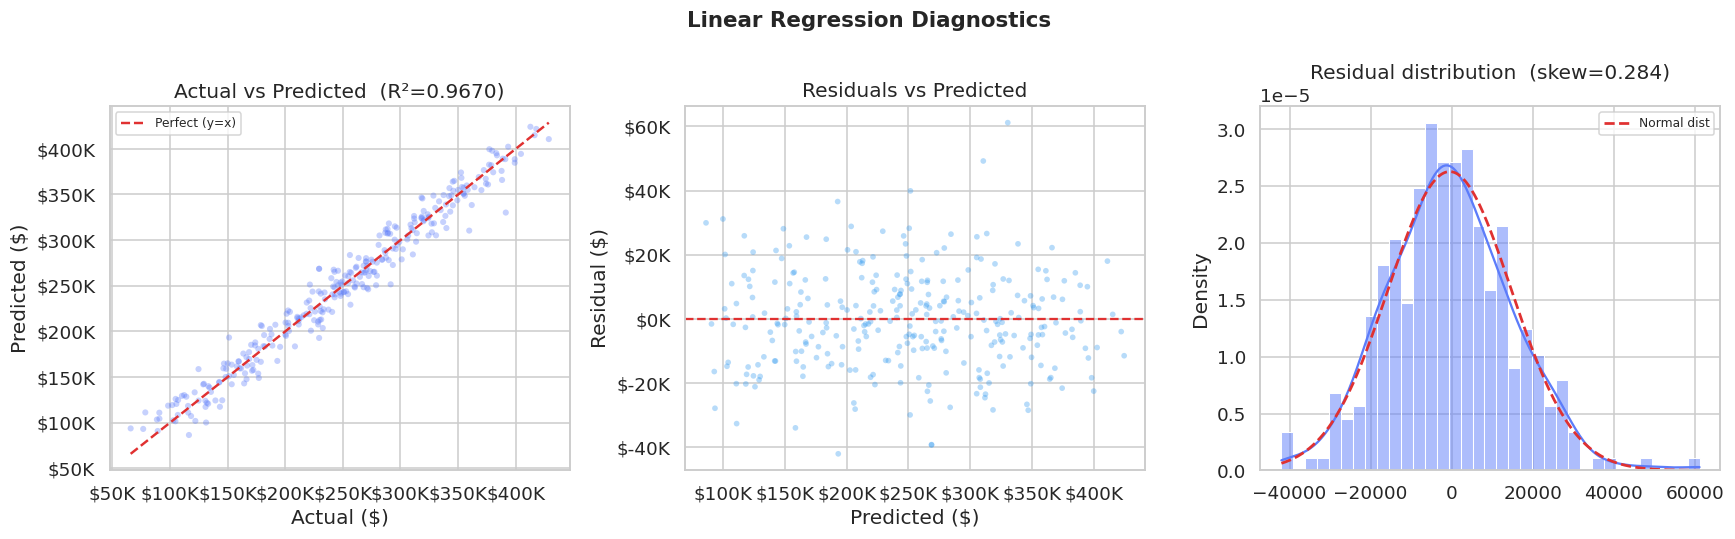

In [12]:
# ── Diagnostic plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Regression Diagnostics", fontsize=14, fontweight="bold")

# Actual vs Predicted
axes[0].scatter(y_test, y_te_pred_lr, alpha=0.35, s=16, color="#5C7CFA", edgecolors="none")
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo,hi],[lo,hi], color="#E03131", lw=1.6, linestyle="--", label="Perfect (y=x)")
axes[0].set_title(f"Actual vs Predicted  (R²={lr_test['R2']:.4f})")
axes[0].set_xlabel("Actual ($)"); axes[0].set_ylabel("Predicted ($)")
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

# Residuals vs Predicted
resid_te = y_test.values - y_te_pred_lr
axes[1].scatter(y_te_pred_lr, resid_te, alpha=0.35, s=14, color="#339AF0", edgecolors="none")
axes[1].axhline(0, color="#E03131", lw=1.5, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted ($)"); axes[1].set_ylabel("Residual ($)")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

# Residual distribution
sns.histplot(resid_te, kde=True, bins=35, color="#5C7CFA", stat="density", ax=axes[2])
mu, sigma = resid_te.mean(), resid_te.std()
x_range = np.linspace(resid_te.min(), resid_te.max(), 300)
axes[2].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
             color="#E03131", lw=1.8, linestyle="--", label="Normal dist")
axes[2].set_title(f"Residual distribution  (skew={stats.skew(resid_te):.3f})")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


In [13]:
# ── Train with sensible constraints ──────────────────────────────────
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=20,
                            min_samples_leaf=10, random_state=42)
t0 = time.perf_counter()
dt.fit(X_train_sc, y_train)
dt_time = time.perf_counter() - t0

y_tr_pred_dt = dt.predict(X_train_sc)
y_te_pred_dt = dt.predict(X_test_sc)
dt_train = get_metrics(y_train, y_tr_pred_dt)
dt_test  = get_metrics(y_test,  y_te_pred_dt)

print(f"Decision Tree trained in {dt_time*1000:.1f} ms")
print(f"  {'Metric':<8}  {'Train':>12}  {'Test':>12}")
print(f"  {'-'*36}")
print(f"  {'R2':<8}  {dt_train['R2']:>12.4f}  {dt_test['R2']:>12.4f}")
print(f"  {'MAE':<8}  ${dt_train['MAE']:>11,.0f}  ${dt_test['MAE']:>11,.0f}")
print(f"  {'RMSE':<8}  ${dt_train['RMSE']:>11,.0f}  ${dt_test['RMSE']:>11,.0f}")
print(f"\nOverfit gap: {dt_train['R2'] - dt_test['R2']:.4f}")


Decision Tree trained in 9.7 ms
  Metric           Train          Test
  ------------------------------------
  R2              0.9520        0.9226
  MAE       $     14,722  $     17,800
  RMSE      $     18,441  $     23,240

Overfit gap: 0.0294


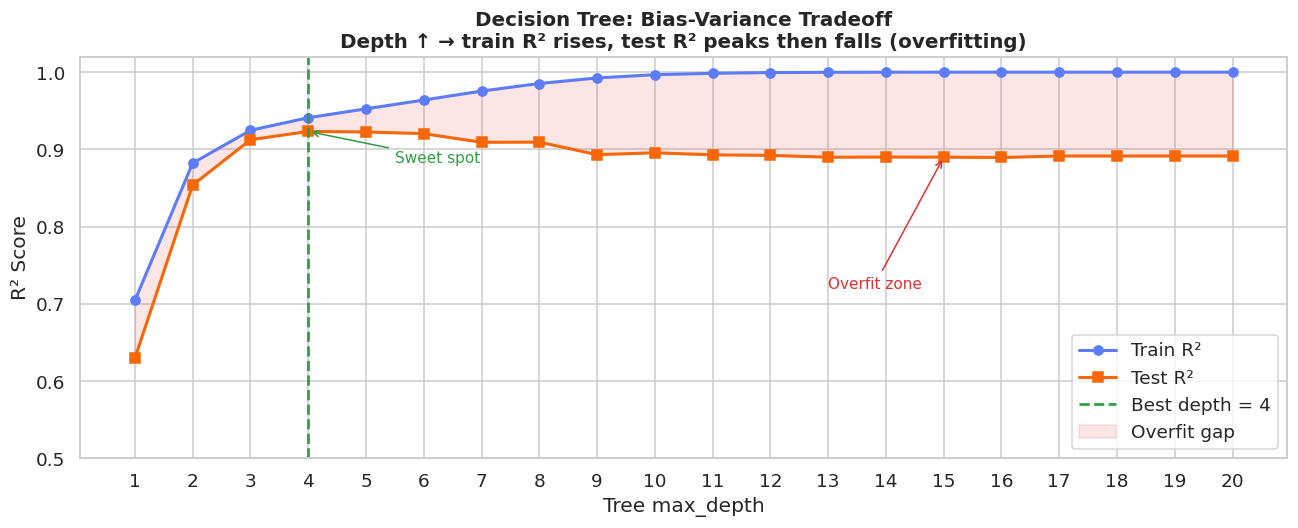

Optimal depth: 4  (Test R²=0.9233)


In [14]:
# ── Bias-variance tradeoff curve ──────────────────────────────────────
depths    = list(range(1, 21))
r2_tr_c, r2_te_c = [], []

for d in depths:
    _dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    _dt.fit(X_train_sc, y_train)
    r2_tr_c.append(r2_score(y_train, _dt.predict(X_train_sc)))
    r2_te_c.append(r2_score(y_test,  _dt.predict(X_test_sc)))

best_depth = depths[np.argmax(r2_te_c)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(depths, r2_tr_c, "o-", color="#5C7CFA", lw=2, ms=6, label="Train R²")
ax.plot(depths, r2_te_c, "s-", color="#F76707", lw=2, ms=6, label="Test R²")
ax.axvline(best_depth, color="#2F9E44", lw=1.8, linestyle="--",
           label=f"Best depth = {best_depth}")
ax.fill_between(depths, r2_tr_c, r2_te_c, alpha=0.12, color="#E03131",
                label="Overfit gap")
ax.set_xlabel("Tree max_depth"); ax.set_ylabel("R² Score")
ax.set_title("Decision Tree: Bias-Variance Tradeoff\n"
             "Depth ↑ → train R² rises, test R² peaks then falls (overfitting)",
             fontsize=13, fontweight="bold")
ax.legend(); ax.set_ylim(0.5, 1.02); ax.set_xticks(depths)
ax.annotate("Overfit zone", xy=(15, r2_te_c[14]), xytext=(13, 0.72),
            arrowprops=dict(arrowstyle="->", color="#E03131"),
            color="#E03131", fontsize=10)
ax.annotate("Sweet spot", xy=(best_depth, max(r2_te_c)),
            xytext=(best_depth+1.5, max(r2_te_c)-0.04),
            arrowprops=dict(arrowstyle="->", color="#2F9E44"),
            color="#2F9E44", fontsize=10)
plt.tight_layout(); plt.show()
print(f"Optimal depth: {best_depth}  (Test R²={max(r2_te_c):.4f})")


In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',   # key: each split sees only sqrt(42)≈6 features
    n_jobs=-1,             # use all CPU cores
    random_state=42,
)
t0 = time.perf_counter()
rf.fit(X_train_sc, y_train)
rf_time = time.perf_counter() - t0

y_tr_pred_rf = rf.predict(X_train_sc)
y_te_pred_rf = rf.predict(X_test_sc)
rf_train = get_metrics(y_train, y_tr_pred_rf)
rf_test  = get_metrics(y_test,  y_te_pred_rf)

print(f"Random Forest trained in {rf_time:.1f} s  (200 trees)")
print(f"  {'Metric':<8}  {'Train':>12}  {'Test':>12}")
print(f"  {'-'*36}")
print(f"  {'R2':<8}  {rf_train['R2']:>12.4f}  {rf_test['R2']:>12.4f}")
print(f"  {'MAE':<8}  ${rf_train['MAE']:>11,.0f}  ${rf_test['MAE']:>11,.0f}")
print(f"  {'RMSE':<8}  ${rf_train['RMSE']:>11,.0f}  ${rf_test['RMSE']:>11,.0f}")
print(f"\nOverfit gap: {rf_train['R2'] - rf_test['R2']:.4f}")


Random Forest trained in 0.3 s  (200 trees)
  Metric           Train          Test
  ------------------------------------
  R2              0.9741        0.9441
  MAE       $     10,540  $     15,581
  RMSE      $     13,558  $     19,757

Overfit gap: 0.0300


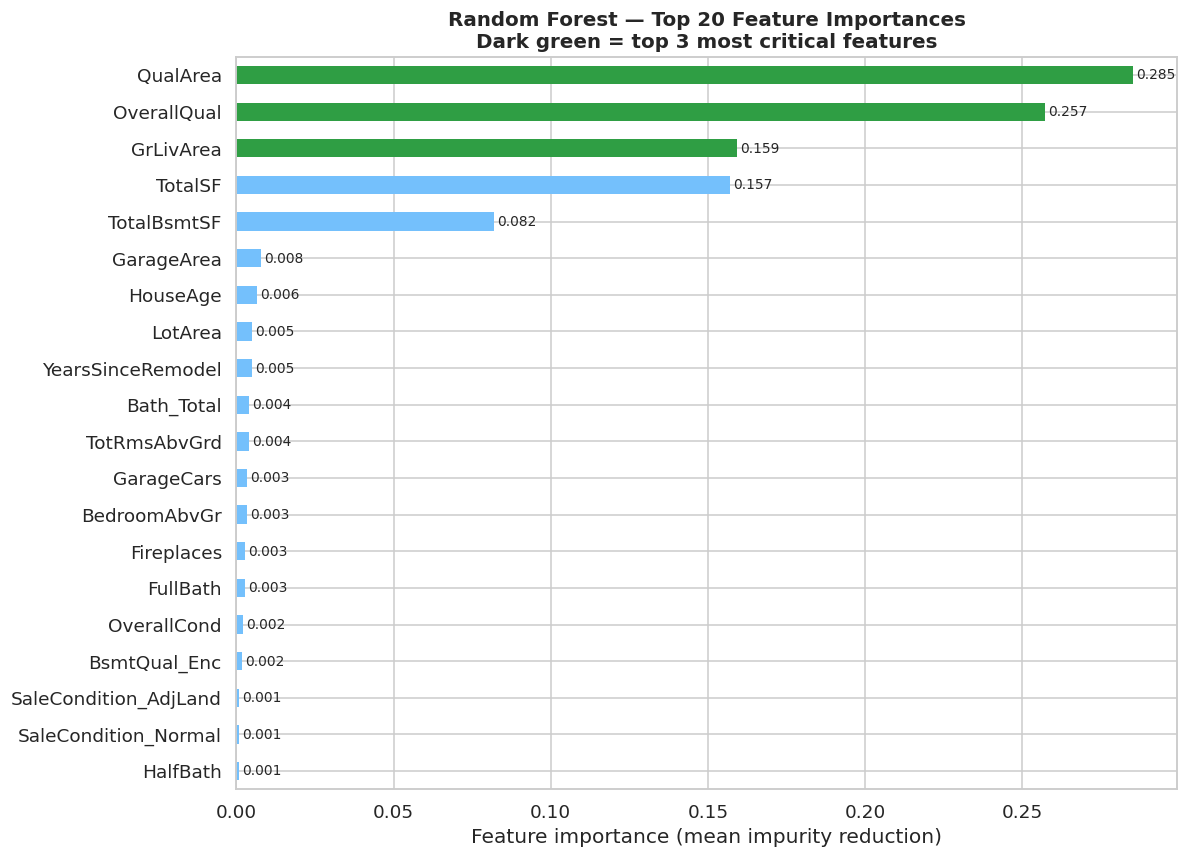


Top 5 features by importance:
  QualArea                   0.2851  (28.5% of model power)
  OverallQual                0.2571  (25.7% of model power)
  GrLivArea                  0.1593  (15.9% of model power)
  TotalSF                    0.1570  (15.7% of model power)
  TotalBsmtSF                0.0820  (8.2% of model power)


In [16]:
# ── Feature importances ───────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train_sc.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors = ["#2F9E44" if i < 3 else "#74C0FC" for i in range(len(top20))]
top20.sort_values().plot.barh(ax=ax, color=colors[::-1], edgecolor="none")
ax.set_xlabel("Feature importance (mean impurity reduction)")
ax.set_title("Random Forest — Top 20 Feature Importances\n"
             "Dark green = top 3 most critical features",
             fontsize=13, fontweight="bold")
for patch in ax.patches:
    w = patch.get_width()
    ax.text(w+0.001, patch.get_y()+patch.get_height()/2,
            f"{w:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print("\nTop 5 features by importance:")
for feat, imp in top20.head(5).items():
    print(f"  {feat:<25}  {imp:.4f}  ({imp*100:.1f}% of model power)")


In [17]:
# ── Comparison table ──────────────────────────────────────────────────
results = {
    "Linear Regression": {"train": lr_train, "test": lr_test, "time": lr_time},
    "Decision Tree"    : {"train": dt_train, "test": dt_test, "time": dt_time},
    "Random Forest"    : {"train": rf_train, "test": rf_test, "time": rf_time},
}

rows = []
for name, res in results.items():
    gap = res["train"]["R2"] - res["test"]["R2"]
    rows.append({
        "Model"       : name,
        "Train R²"    : f"{res['train']['R2']:.4f}",
        "Test R²"     : f"{res['test']['R2']:.4f}",
        "Test MAE"    : f"${res['test']['MAE']:>10,.0f}",
        "Test RMSE"   : f"${res['test']['RMSE']:>10,.0f}",
        "Test MAPE"   : f"{res['test']['MAPE']:.2f}%",
        "Overfit Gap" : f"{gap:.4f}",
        "Fit Time"    : f"{res['time']*1000:.0f} ms" if res['time']<1 else f"{res['time']:.1f} s",
    })

cmp = pd.DataFrame(rows).set_index("Model")
print(cmp.to_string())
best = max(results, key=lambda n: results[n]["test"]["R2"])
print(f"\n★  Best model by Test R²: {best}")


                  Train R² Test R²     Test MAE    Test RMSE Test MAPE Overfit Gap Fit Time
Model                                                                                      
Linear Regression   0.9679  0.9670  $    11,870  $    15,185     5.73%      0.0010    26 ms
Decision Tree       0.9520  0.9226  $    17,800  $    23,240     8.22%      0.0294    10 ms
Random Forest       0.9741  0.9441  $    15,581  $    19,757     7.53%      0.0300   331 ms

★  Best model by Test R²: Linear Regression


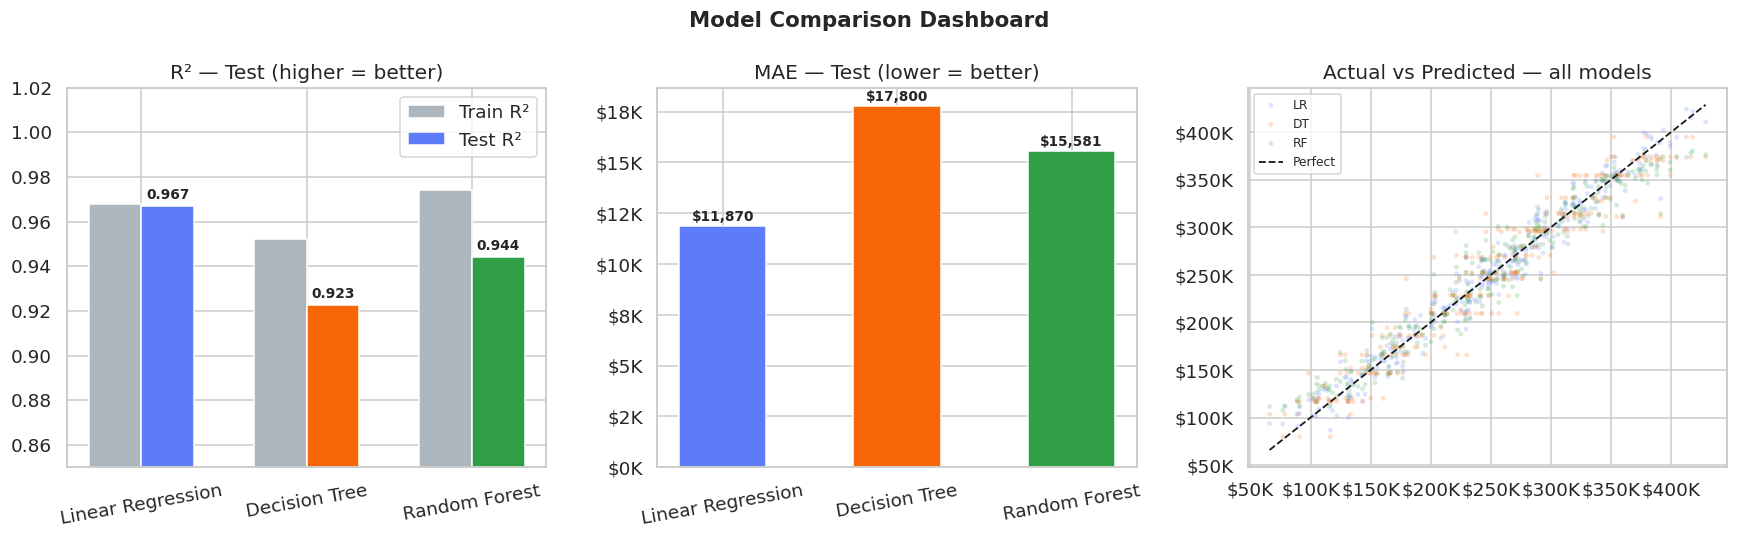

In [18]:
# ── Comparison charts ─────────────────────────────────────────────────
model_names   = list(results.keys())
r2_train_vals = [results[n]['train']['R2']  for n in model_names]
r2_test_vals  = [results[n]['test']['R2']   for n in model_names]
mae_test_vals = [results[n]['test']['MAE']  for n in model_names]

x  = np.arange(len(model_names))
w  = 0.32
bar_colors = ['#5C7CFA','#F76707','#2F9E44']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison Dashboard", fontsize=14, fontweight="bold")

# R² grouped
ax = axes[0]
ax.bar(x-w/2, r2_train_vals, w, label="Train R²", color="#ADB5BD")
b2 = ax.bar(x+w/2, r2_test_vals, w, label="Test R²", color=bar_colors)
for bar, val in zip(b2, r2_test_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=10)
ax.set_title("R² — Test (higher = better)"); ax.legend(); ax.set_ylim(0.85,1.02)

# MAE
ax = axes[1]
bars = ax.bar(x, mae_test_vals, 0.5, color=bar_colors)
for bar, val in zip(bars, mae_test_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+100, f"${val:,.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=10)
ax.set_title("MAE — Test (lower = better)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"${v/1000:.0f}K"))

# Actual vs Predicted — all 3 on one axis
ax = axes[2]
preds  = [y_te_pred_lr, y_te_pred_dt, y_te_pred_rf]
labels = ["LR", "DT", "RF"]
for pred, color, label in zip(preds, bar_colors, labels):
    ax.scatter(y_test, pred, alpha=0.2, s=10, color=color, edgecolors="none", label=label)
lo, hi = y_test.min(), y_test.max()
ax.plot([lo,hi],[lo,hi], "k--", lw=1.2, label="Perfect")
ax.set_title("Actual vs Predicted — all models")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

plt.tight_layout(); plt.show()


In [19]:
import json
from datetime import datetime

os.makedirs('/kaggle/working/models', exist_ok=True)

# Pick the best model by test R²
best_name  = max(results, key=lambda n: results[n]['test']['R2'])
best_model = {"Linear Regression": lr, "Decision Tree": dt, "Random Forest": rf}[best_name]

print(f"Selected model: {best_name}  (Test R²={results[best_name]['test']['R2']:.4f})")

# Save each artefact
joblib.dump(best_model, '/kaggle/working/models/best_model.pkl',  compress=3)
joblib.dump(scaler,     '/kaggle/working/models/scaler.pkl')
joblib.dump(scale_cols, '/kaggle/working/models/scale_cols.pkl')
joblib.dump(list(X_train_sc.columns), '/kaggle/working/models/feature_names.pkl')

metadata = {
    "model_name"   : best_name,
    "model_version": "1.0.0",
    "trained_at"   : datetime.now().isoformat(timespec="seconds"),
    "training_rows": len(X_train_sc),
    "test_rows"    : len(X_test_sc),
    "n_features"   : X_train_sc.shape[1],
    "feature_names": list(X_train_sc.columns),
    "target_column": "SalePrice",
    "metrics": {
        "train_r2"     : round(results[best_name]['train']['R2'],  4),
        "test_r2"      : round(results[best_name]['test']['R2'],   4),
        "test_mae_usd" : round(results[best_name]['test']['MAE'],  2),
        "test_rmse_usd": round(results[best_name]['test']['RMSE'], 2),
        "test_mape_pct": round(results[best_name]['test']['MAPE'], 2),
    },
}
with open('/kaggle/working/models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Round-trip verification
loaded = joblib.load('/kaggle/working/models/best_model.pkl')
orig   = best_model.predict(X_test_sc)
reload = loaded.predict(X_test_sc)
match  = np.allclose(orig, reload, rtol=1e-6)
print(f"\nRound-trip check: {match}  ✅" if match else "\n⚠️  Mismatch — check bundle!")
print(f"\nSaved files:")
for f in os.listdir('/kaggle/working/models'):
    sz = os.path.getsize(f'/kaggle/working/models/{f}')
    print(f"  {f:<30} {sz/1024:.1f} KB")


Selected model: Linear Regression  (Test R²=0.9670)

Round-trip check: True  ✅

Saved files:
  feature_names.pkl              0.7 KB
  model_metadata.json            1.3 KB
  best_model.pkl                 1.6 KB
  scaler.pkl                     1.5 KB
  scale_cols.pkl                 0.2 KB


In [20]:
BSMT_MAP_PRED = {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
TRAINED_FEATS = list(X_train_sc.columns)
SCALE_COLS_P  = scale_cols

def predict_price(raw: dict) -> dict:
    """
    raw : dict of house features (same names as original columns)
    Returns : dict with predicted_price, low_estimate, high_estimate
    """
    df_p = pd.DataFrame([raw])

    # Feature engineering — same as training
    df_p['HouseAge']          = df_p['YrSold'] - df_p['YearBuilt']
    df_p['YearsSinceRemodel'] = df_p['YrSold'] - df_p['YearRemodAdd']
    df_p['TotalSF']           = df_p['GrLivArea'] + df_p['TotalBsmtSF']
    df_p['Bath_Total']        = df_p['FullBath']  + 0.5 * df_p['HalfBath']
    df_p['QualArea']          = df_p['OverallQual'] * df_p['GrLivArea']
    df_p.drop(columns=['YearBuilt','YearRemodAdd','YrSold','MoSold'],
              errors='ignore', inplace=True)

    # Ordinal encode
    df_p['BsmtQual_Enc'] = df_p['BsmtQual'].map(BSMT_MAP_PRED).fillna(0).astype(int)
    df_p.drop(columns=['BsmtQual'], inplace=True)

    # OHE
    ohe = ['Neighborhood','HouseStyle','GarageType','CentralAir','SaleCondition']
    df_p = pd.get_dummies(df_p, columns=ohe, drop_first=True, dtype=int)

    # Align to training schema
    for col in TRAINED_FEATS:
        if col not in df_p.columns:
            df_p[col] = 0
    df_p = df_p[TRAINED_FEATS]

    # Scale
    df_p[SCALE_COLS_P] = scaler.transform(df_p[SCALE_COLS_P])

    # Predict
    price  = float(best_model.predict(df_p)[0])
    price  = max(price, 10_000)
    mape   = metadata['metrics']['test_mape_pct'] / 100
    margin = price * mape * 1.65
    return {
        "predicted_price": round(price, -2),
        "low_estimate"   : round(max(price - margin, 10_000), -2),
        "high_estimate"  : round(price + margin, -2),
    }


# ── Test cases ────────────────────────────────────────────────────────
test_houses = [
    {
        "label"       : "Modest starter  (OldTown, quality 4)",
        "OverallQual" : 4,  "OverallCond": 5,  "GrLivArea"  : 750,
        "TotalBsmtSF" : 500,"GarageCars" : 1,  "GarageArea" : 240,
        "BedroomAbvGr": 2,  "FullBath"   : 1,  "HalfBath"   : 0,
        "TotRmsAbvGrd": 4,  "Fireplaces" : 0,  "LotArea"    : 6000,
        "YearBuilt"   : 1955,"YearRemodAdd":1955,"YrSold"   : 2008,
        "MoSold"      : 6,  "BsmtQual"   :"Fa","Neighborhood":"OldTown",
        "HouseStyle"  :"1Story","GarageType":"Detchd",
        "CentralAir"  :"N", "SaleCondition":"Normal",
    },
    {
        "label"       : "Average family  (CollgCr, quality 6)",
        "OverallQual" : 6,  "OverallCond": 5,  "GrLivArea"  : 1500,
        "TotalBsmtSF" : 900,"GarageCars" : 2,  "GarageArea" : 440,
        "BedroomAbvGr": 3,  "FullBath"   : 2,  "HalfBath"   : 1,
        "TotRmsAbvGrd": 7,  "Fireplaces" : 1,  "LotArea"    : 9500,
        "YearBuilt"   : 1985,"YearRemodAdd":2001,"YrSold"   : 2008,
        "MoSold"      : 5,  "BsmtQual"   :"TA","Neighborhood":"CollgCr",
        "HouseStyle"  :"1Story","GarageType":"Attchd",
        "CentralAir"  :"Y", "SaleCondition":"Normal",
    },
    {
        "label"       : "Luxury property (NridgHt, quality 9)",
        "OverallQual" : 9,  "OverallCond": 8,  "GrLivArea"  : 2800,
        "TotalBsmtSF" : 2000,"GarageCars": 3,  "GarageArea" : 720,
        "BedroomAbvGr": 4,  "FullBath"   : 3,  "HalfBath"   : 1,
        "TotRmsAbvGrd": 10, "Fireplaces" : 3,  "LotArea"    : 18000,
        "YearBuilt"   : 2003,"YearRemodAdd":2008,"YrSold"   : 2009,
        "MoSold"      : 9,  "BsmtQual"   :"Ex","Neighborhood":"NridgHt",
        "HouseStyle"  :"2Story","GarageType":"Attchd",
        "CentralAir"  :"Y", "SaleCondition":"Normal",
    },
]

print(f"{'House':<42} {'Predicted':>12}  {'90% Range'}")
print("-" * 80)
for house in test_houses:
    raw    = {k:v for k,v in house.items() if k != 'label'}
    result = predict_price(raw)
    lo, hi = result['low_estimate'], result['high_estimate']
    print(f"{house['label']:<42} ${result['predicted_price']:>10,.0f}  "
          f"${lo:,.0f} – ${hi:,.0f}")

print(f"\nModel : {metadata['model_name']}")
print(f"Test R²: {metadata['metrics']['test_r2']}  |  "
      f"MAE: ${metadata['metrics']['test_mae_usd']:,.0f}  |  "
      f"MAPE: {metadata['metrics']['test_mape_pct']:.1f}%")


House                                         Predicted  90% Range
--------------------------------------------------------------------------------
Modest starter  (OldTown, quality 4)       $   137,000  $124,100 – $150,000
Average family  (CollgCr, quality 6)       $   250,300  $226,600 – $274,000
Luxury property (NridgHt, quality 9)       $   431,300  $390,500 – $472,000

Model : Linear Regression
Test R²: 0.967  |  MAE: $11,870  |  MAPE: 5.7%
